<a href="https://colab.research.google.com/github/Ha1ion/DM2025-Lab2-Exercise/blob/main/DM2025_Lab2_Master_Phase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Colab Environment Setup**

In [1]:
import kagglehub

# Importing our Google News Data
google_news_vectors_path = kagglehub.dataset_download('didiersalazar/google-news-vectors')

print('Data source import complete.')


Using Colab cache for faster access to the 'google-news-vectors' dataset.
Data source import complete.


In [2]:
google_news_vectors_path

'/kaggle/input/google-news-vectors'

In [3]:
# Clone Lab 2's github repository to get all of our material first

!git clone https://github.com/difersalest/DM2025-Lab2-Exercise.git

fatal: destination path 'DM2025-Lab2-Exercise' already exists and is not an empty directory.


In [4]:
# Installing all of our dependencies
# The lab in colab was tested with this, and everything should work as intended
# If in your case something is not working please notify the TAs
!pip3 install python-dotenv==1.1.1 gensim==4.3.3 tensorflow==2.20.0 tensorflow-hub==0.16.1 keras==3.11.3 jupyter==1.1.1 scikit-learn==1.7.1 pandas==2.3.2 numpy==1.26.4 matplotlib==3.10.6 plotly==6.3.0 seaborn==0.13.2 nltk==3.9.1 umap-learn==0.5.9.post2

In [5]:
# test code for environment setup
# import library
import dotenv
import gensim
import tensorflow
import tensorflow_hub
import keras
import jupyter
import sklearn
import pandas
import numpy
import matplotlib
import plotly
import seaborn
import nltk
import umap

%matplotlib inline

print("gensim: " + gensim.__version__)
print("tensorflow: " + tensorflow.__version__)
print("keras: " + keras.__version__)

gensim: 4.3.3
tensorflow: 2.20.0
keras: 3.11.3


##### **OPTIONAL: If you want to save your outputs you can send them to your own drive by mounting the drive in the following way (uncomment the lines):**

In [6]:

# Remember to change the directory of your outputs to your folder in the new mounted google drive inside colab
# from google.colab import drive
# drive.mount('/content/drive/')


**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 1](#toc1_)    
  - [Summarized Table of Contents](#toc1_1_)    
  - [Before Starting](#toc1_2_)    
  - [Introduction](#toc1_3_)    
  - [**1. Data Preparation**](#toc1_4_)    
  - [**1.1 Load data**](#toc1_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_1_1_1_)    
    - [**1.2 Save data**](#toc1_5_2_)    
    - [**1.3 Exploratory data analysis (EDA)**](#toc1_5_3_)    
  - [**2. Feature engineering**](#toc1_6_)    
    - [Using Bag of Words](#toc1_6_1_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_6_1_1_1_)    
  - [**3. Model**](#toc1_7_)    
    - [**3.1 Decision Trees**](#toc1_7_1_)    
  - [**4. Results Evaluation**](#toc1_8_)    
        - [**>>> Exercise 3 (Take home):**](#toc1_8_1_1_1_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_8_1_1_2_)    
        - [**>>> Exercise 5 (Take home):**](#toc1_8_1_1_3_)    
  - [**5. Other things you can try**](#toc1_9_)    
  - [**6. Deep Learning**](#toc1_10_)    
    - [**6.1 Prepare data (X, y)**](#toc1_10_1_)    
    - [**6.2 Deal with categorical label (y)**](#toc1_10_2_)    
    - [**6.3 Build model**](#toc1_10_3_)    
    - [**6.4 Train**](#toc1_10_4_)    
    - [**6.5 Predict on testing data**](#toc1_10_5_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_10_5_1_1_)    
    - [Note](#toc1_10_6_)    
    - [More Information for your reference](#toc1_10_7_)    
  - [**7. Word2Vector**](#toc1_11_)    
    - [**7.1 Prepare training corpus**](#toc1_11_1_)    
    - [**7.2 Training our model**](#toc1_11_2_)    
    - [**7.3 Generating word vector (embeddings)**](#toc1_11_3_)    
    - [**7.4 Using a pre-trained w2v model**](#toc1_11_4_)    
      - [(1) Download model by yourself](#toc1_11_4_1_)    
      - [(2) Using gensim api](#toc1_11_4_2_)    
    - [**7.5 king + woman - man = ?**](#toc1_11_5_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_11_5_1_1_)    
  - [**8. Clustering: k-means**](#toc1_12_)    
      - [Basic concept](#toc1_12_1_1_)    
  - [**9. High-dimension Visualization: t-SNE and UMAP**](#toc1_13_)    
    - [**9.1 Prepare visualizing target**](#toc1_13_1_)    
    - [**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc1_13_2_)    
        - [**>>> Exercise 8 (Take home):**](#toc1_13_2_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 1](#toc0_)
In this lab's phase 1 session we will focus on the use of Neural Word Embeddings

## <a id='toc1_1_'></a>[Summarized Table of Contents](#toc0_)
- **Phase 1:**
1. Data preparation
2. Feature engineering
3. Model
4. Results evaluation
5. Other things you could try
6. Deep Learning
7. Word to Vector
8. Clustering
9. High-dimension Visualization


## <a id='toc1_2_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_3_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](https://drive.google.com/uc?export=view&id=1qurztXdx30Wl2vkCZg7KXXJYJXcE6YR_)

---
## <a id='toc1_4_'></a>[**1. Data Preparation**](#toc0_)

Before beggining the lab, please make sure to download the [Google News Dataset](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit) and place it in a folder named "GoogleNews" in the same directory as this file.

---
## <a id='toc1_5_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [7]:
import pandas as pd

### training data
anger_train = pd.read_csv("./DM2025-Lab2-Exercise/data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("./DM2025-Lab2-Exercise/data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("./DM2025-Lab2-Exercise/data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("./DM2025-Lab2-Exercise/data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [8]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [9]:
### testing data
anger_test = pd.read_csv("./DM2025-Lab2-Exercise/data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("./DM2025-Lab2-Exercise/data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("./DM2025-Lab2-Exercise/data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("./DM2025-Lab2-Exercise/data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [10]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [11]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
##### <a id='toc1_5_1_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)
Plot word frequency for Top 30 words in both train and test dataset. (Hint: refer to DM lab 1)


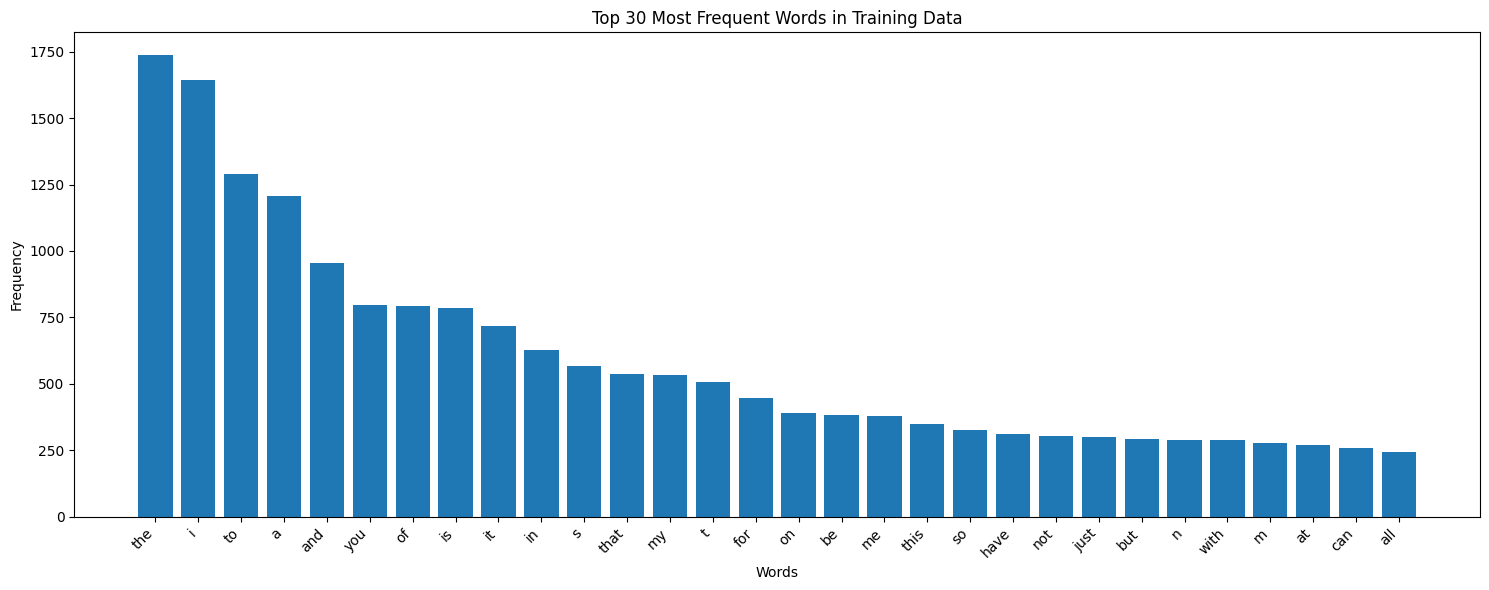

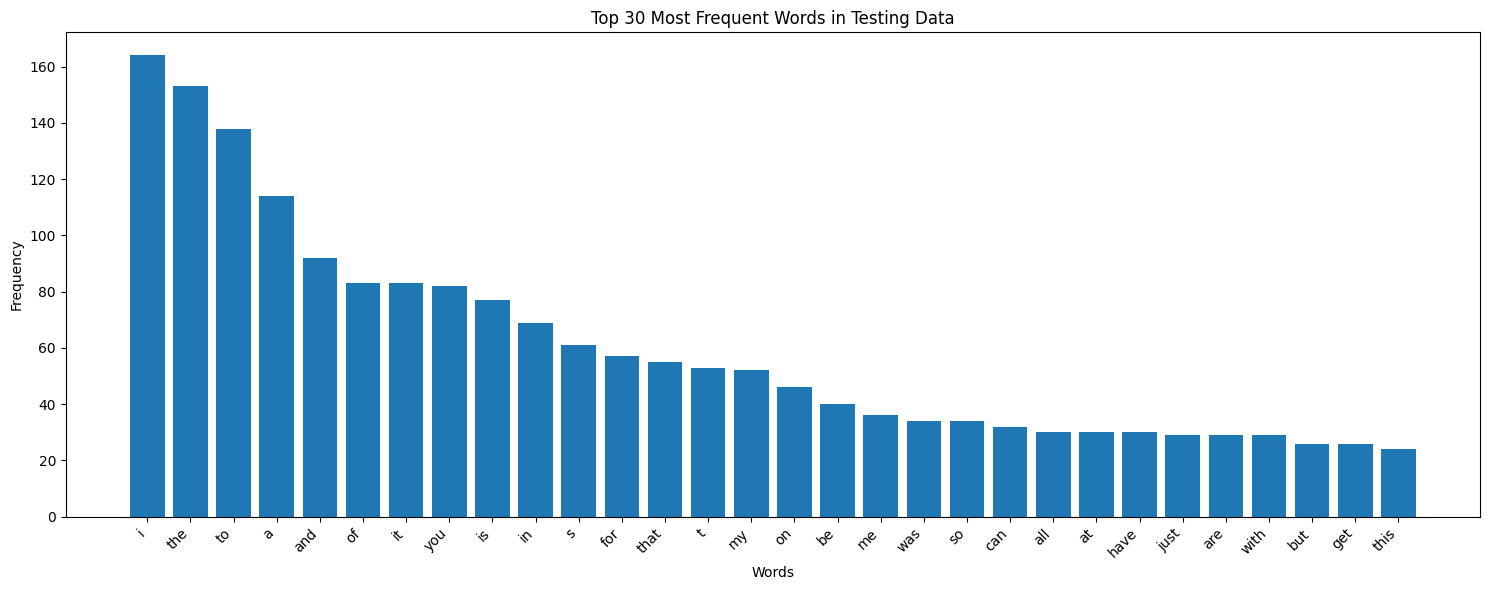

In [12]:
# Answer here
import pandas as pd
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import re


# Combine all text from the 'text' column in train_df into one large string
train_text = ' '.join(train_df['text'].astype(str).tolist())

train_words = re.findall(r'\b\w+\b', train_text.lower())

train_word_counts = Counter(train_words)

top_30_train_words = train_word_counts.most_common(30)

train_words_to_plot, train_counts_to_plot = zip(*top_30_train_words)

plt.figure(figsize=(15, 6))
plt.bar(train_words_to_plot, train_counts_to_plot)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 30 Most Frequent Words in Training Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Process Testing Data ---

test_text = ' '.join(test_df['text'].astype(str).tolist())

test_words = re.findall(r'\b\w+\b', test_text.lower())

test_word_counts = Counter(test_words)

top_30_test_words = test_word_counts.most_common(30)

test_words_to_plot, test_counts_to_plot = zip(*top_30_test_words)

# Plotting for testing data
plt.figure(figsize=(15, 6))
plt.bar(test_words_to_plot, test_counts_to_plot)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 30 Most Frequent Words in Testing Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
### <a id='toc1_5_2_'></a>[**1.2 Save data**](#toc0_)

We will save our data in Pickle format. The pickle module implements binary protocols for serializing and de-serializing a Python object structure.   
  
Some advantages for using pickle structure:  
* Because it stores the attribute type, it's more convenient for cross-platform use.  
* When your data is huge, it could use less space to store also consume less loading time.   

In [13]:
# save to pickle file
train_df.to_pickle("./DM2025-Lab2-Exercise/data/train_df.pkl")
test_df.to_pickle("./DM2025-Lab2-Exercise/data/test_df.pkl")

In [14]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./DM2025-Lab2-Exercise/data/train_df.pkl")
test_df = pd.read_pickle("./DM2025-Lab2-Exercise/data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
### <a id='toc1_5_3_'></a>[**1.3 Exploratory data analysis (EDA)**](#toc0_)

Again, before getting our hands dirty, we need to explore a little bit and understand the data we're dealing with.

In [15]:
# group to find distribution
train_df.groupby(['emotion']).count()['text']

,text
emotion,
anger,857
fear,1147
joy,823
sadness,786


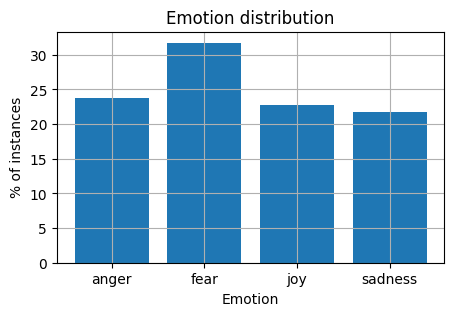

In [16]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# the histogram of the data
labels = train_df['emotion'].unique()
post_total = len(train_df)
df1 = train_df.groupby(['emotion']).count()['text']
df1 = df1.apply(lambda x: round(x*100/post_total,3))

#plot
fig, ax = plt.subplots(figsize=(5,3))
plt.bar(df1.index,df1.values)

#arrange
plt.ylabel('% of instances')
plt.xlabel('Emotion')
plt.title('Emotion distribution')
plt.grid(True)
plt.show()

---

## <a id='toc1_6_'></a>[**2. Feature engineering**](#toc0_)
### <a id='toc1_6_1_'></a>[Using Bag of Words](#toc0_)
Using scikit-learn ```CountVectorizer``` perform word frequency and use these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

In [18]:
# build analyzers (bag-of-words)
BOW_vectorizer = CountVectorizer()

In [19]:
# 1. Learn a vocabulary dictionary of all tokens in the raw documents.
BOW_vectorizer.fit(train_df['text'])

# 2. Transform documents to document-term matrix.
train_data_BOW_features = BOW_vectorizer.transform(train_df['text'])
test_data_BOW_features = BOW_vectorizer.transform(test_df['text'])

In [20]:
# check the result
train_data_BOW_features

<3613x10115 sparse matrix of type '<class 'numpy.int64'>'
	with 51467 stored elements in Compressed Sparse Row format>

In [21]:
type(train_data_BOW_features)

scipy.sparse._csr.csr_matrix

In [22]:
# add .toarray() to show
train_data_BOW_features.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [23]:
# check the dimension
train_data_BOW_features.shape

(3613, 10115)

In [24]:
# observe some feature names
feature_names = BOW_vectorizer.get_feature_names_out()
feature_names[100:110]

array(['2k17', '2much', '2nd', '30', '300', '301', '30am', '30pm', '30s',
       '31'], dtype=object)

The embedding is done. We can technically feed this into our model. However, depending on the embedding technique you use and your model, your accuracy might not be as high, because:

* curse of dimensionality  (we have 10,115 dimension now)
* some important features are ignored (for example, some models using emoticons yeld better performance than counterparts)

In [25]:
"😂" in feature_names

False

Let's try using another tokenizer below.

In [26]:
import nltk
nltk.download('punkt_tab')
# build analyzers (bag-of-words)
BOW_500 = CountVectorizer(max_features=500, tokenizer=nltk.word_tokenize)

# apply analyzer to training data
BOW_500.fit(train_df['text'])

train_data_BOW_features_500 = BOW_500.transform(train_df['text'])

## check dimension
train_data_BOW_features_500.shape

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(3613, 500)

In [27]:
train_data_BOW_features_500.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 2, 2, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 4, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [28]:
# observe some feature names
feature_names_500 = BOW_500.get_feature_names_out()
feature_names_500[100:110]

array(['change', 'cheer', 'cheerful', 'cheering', 'cheery', 'come',
       'comes', 'could', 'country', 'cry'], dtype=object)

In [29]:
"😂" in feature_names_500

True

---
##### <a id='toc1_6_1_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)
Generate an embedding using the TF-IDF vectorizer instead of th BOW one with 1000 features and show the feature names for features [100:110].

In [30]:
# Answer here
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk

tfidf_vectorizer = TfidfVectorizer(max_features=1000, tokenizer=nltk.word_tokenize)

tfidf_vectorizer.fit(train_df['text'])

feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Feature names [100:110] (TF-IDF, 1000 features):")
print(feature_names_tfidf[100:110])

Feature names [100:110] (TF-IDF, 1000 features):
['attacks' 'awareness' 'away' 'awe' 'awesome' 'awful' 'b' 'baby' 'back'
 'bad']


---
## <a id='toc1_7_'></a>[**3. Model**](#toc0_)
### <a id='toc1_7_1_'></a>[**3.1 Decision Trees**](#toc0_)
Using scikit-learn ```DecisionTreeClassifier``` performs word frequency and uses these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [31]:
from sklearn.tree import DecisionTreeClassifier

# for a classificaiton problem, you need to provide both training & testing data
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## take a look at data dimension is a good habit  :)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [32]:
## build DecisionTree model
DT_model = DecisionTreeClassifier(random_state=1)

## training!
DT_model = DT_model.fit(X_train, y_train)

## predict!
y_train_pred = DT_model.predict(X_train)
y_test_pred = DT_model.predict(X_test)

## so we get the pred result
y_test_pred[:10]

array(['sadness', 'fear', 'anger', 'anger', 'joy', 'joy', 'sadness',
       'fear', 'anger', 'joy'], dtype=object)

---
## <a id='toc1_8_'></a>[**4. Results Evaluation**](#toc0_)

Now we will check the results of our model's performance

In [33]:
## accuracy
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_true=y_train, y_pred=y_train_pred)
acc_test = accuracy_score(y_true=y_test, y_pred=y_test_pred)

print('training accuracy: {}'.format(round(acc_train, 2)))
print('testing accuracy: {}'.format(round(acc_test, 2)))


training accuracy: 0.99
testing accuracy: 0.66


In [34]:
## precision, recall, f1-score,
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=y_test_pred))

              precision    recall  f1-score   support

       anger       0.62      0.71      0.67        84
        fear       0.67      0.63      0.65       110
         joy       0.74      0.67      0.70        79
     sadness       0.62      0.64      0.63        74

    accuracy                           0.66       347
   macro avg       0.66      0.66      0.66       347
weighted avg       0.66      0.66      0.66       347



In [35]:
## check by confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred)
print(cm)

[[60 11  7  6]
 [20 69  7 14]
 [ 6 11 53  9]
 [10 12  5 47]]


In [36]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from:
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))

    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

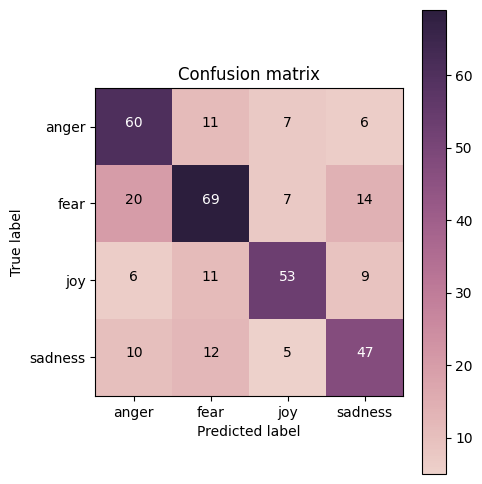

In [37]:
# plot your confusion matrix
my_tags = ['anger', 'fear', 'joy', 'sadness']
plot_confusion_matrix(cm, classes=my_tags, title='Confusion matrix')

---
##### <a id='toc1_8_1_1_1_'></a>[**>>> Exercise 3 (Take home):**](#toc0_)
Can you interpret the results above? What do they mean?

The results indicate the following about the Decision Tree model's performance:

1.  **Accuracy**:
    * The **training accuracy is 0.99**, meaning the model performs almost perfectly on the data it was trained on.
    * The **testing accuracy is 0.66**, meaning the model correctly predicts the emotion for about 66% of the unseen test data samples.
    * The large difference between training and testing accuracy (0.99 vs 0.66) is a strong indicator of **overfitting**. The model has learned the training data too well, including its noise, and doesn't generalize effectively to new data.

2.  **Classification Report**:
    * **Precision** (how many predictions for a class were correct) varies: 'joy' has the highest (0.74), while 'anger' and 'sadness' are lower (0.62). This means predictions for 'joy' are more likely to be correct than predictions for 'anger' or 'sadness'.
    * **Recall** (how many actual instances of a class were found) also varies: 'anger' has the highest (0.71), meaning the model identified 71% of all true 'anger' instances. 'Fear' has the lowest recall (0.63).
    * The **F1-score** (balance between precision and recall) is highest for 'joy' (0.70), indicating the best overall performance for this class. 'Sadness' has the lowest F1-score (0.63).
    * The **overall accuracy** is confirmed at 0.66.

3.  **Confusion Matrix**:
    * The diagonal values (60, 69, 53, 47) show the number of correctly classified instances for anger, fear, joy, and sadness, respectively.
    * The off-diagonal values show misclassifications. Notable confusions include:
        * 20 instances of true 'fear' were misclassified as 'anger'.
        * 14 instances of true 'fear' were misclassified as 'sadness'.
        * 11 instances of true 'anger' were misclassified as 'fear'.
        * 11 instances of true 'joy' were misclassified as 'fear'.
        * 12 instances of true 'sadness' were misclassified as 'fear'.
    * This indicates the model struggles particularly in distinguishing 'fear' from 'anger' and 'sadness'. 'Fear' appears frequently involved in misclassifications.

**In summary**: The Decision Tree model is heavily overfit to the training data. Its performance on unseen data is moderate (66% accuracy). It performs best at identifying 'joy' but has difficulty differentiating between the negative emotions, especially involving 'fear'.

---
##### <a id='toc1_8_1_1_2_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)
Build a model using a ```Naive Bayes``` model and train it. What are the testing results?

*Reference*: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

Naive Bayes - Testing Accuracy: 0.71
\nNaive Bayes - Classification Report:
              precision    recall  f1-score   support

       anger       0.65      0.67      0.66        84
        fear       0.74      0.81      0.77       110
         joy       0.77      0.70      0.73        79
     sadness       0.66      0.62      0.64        74

    accuracy                           0.71       347
   macro avg       0.71      0.70      0.70       347
weighted avg       0.71      0.71      0.71       347

\nNaive Bayes - Confusion Matrix:
[[56 14  5  9]
 [ 7 89  5  9]
 [11  7 55  6]
 [12 10  6 46]]


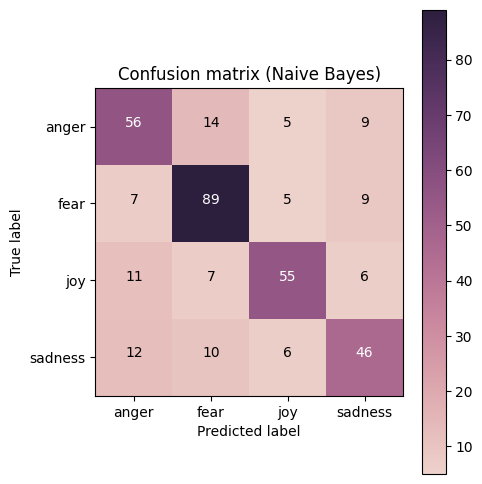

In [38]:
# Answer here
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

y_train_original = train_df['emotion'] # Assuming train_df is still the original loaded dataframe
y_test_original = test_df['emotion']   # Assuming test_df is still the original loaded dataframe

nb_model.fit(X_train, y_train_original)

# Predict on the test data
y_test_pred_nb = nb_model.predict(X_test)


acc_test_nb = accuracy_score(y_true=y_test_original, y_pred=y_test_pred_nb)
print('Naive Bayes - Testing Accuracy: {}'.format(round(acc_test_nb, 2)))

# Print classification report
print('\\nNaive Bayes - Classification Report:')
print(classification_report(y_true=y_test_original, y_pred=y_test_pred_nb))


from sklearn.metrics import confusion_matrix
cm_nb = confusion_matrix(y_true=y_test_original, y_pred=y_test_pred_nb)
print('\\nNaive Bayes - Confusion Matrix:')
print(cm_nb)
plot_confusion_matrix(cm_nb, classes=my_tags, title='Confusion matrix (Naive Bayes)')

---
##### <a id='toc1_8_1_1_3_'></a>[**>>> Exercise 5 (Take home):**](#toc0_)

How do the results from the Naive Bayes model and the Decision Tree model compare? How do you interpret these differences? Use the theoretical background covered in class to try and explain these differences.

Comparing the results of the Naive Bayes (NB) model with the Decision Tree (DT) model using the BOW_500 features:

1.  **Overall Accuracy**:
    * The Naive Bayes model achieved a testing accuracy of **0.71**.
    * The Decision Tree model achieved a testing accuracy of **0.66**.
    * **Interpretation**: The Naive Bayes model performs better overall on the unseen test data compared to the Decision Tree model in this specific setup.

2.  **Per-Class Performance (F1-Score)**:
    * **Anger**: NB (0.66) vs DT (0.67) - DT slightly better.
    * **Fear**: NB (0.77) vs DT (0.65) - NB significantly better.
    * **Joy**: NB (0.73) vs DT (0.70) - NB better.
    * **Sadness**: NB (0.64) vs DT (0.63) - NB slightly better.
    * **Interpretation**: Naive Bayes shows a marked improvement in classifying 'fear' and also performs better for 'joy' and 'sadness'. The Decision Tree was only slightly better for 'anger'. The weighted average F1-score also reflects NB's better overall performance (0.71 vs 0.66).

3.  **Overfitting and Generalization**:
    * The Decision Tree showed strong signs of overfitting, with a training accuracy of 0.99 but a testing accuracy of only 0.66.
    * While the NB model's training accuracy isn't shown, its higher testing accuracy (0.71) suggests it generalizes better to unseen data than the overfit DT model.

4.  **Theoretical Interpretation**:
    * **Decision Trees** learn by creating a set of hierarchical rules (splits) based on features (word counts) to separate the classes. Without constraints (like depth limits), they can create very complex trees that fit the training data perfectly but fail to generalize, leading to overfitting. They can capture interactions between features.
    * **Naive Bayes (specifically MultinomialNB)** works on probabilities using Bayes' theorem. Its "naive" assumption is that features (word counts) are conditionally independent given the class (emotion). While this independence assumption is often violated in text data (word order and combinations matter), it simplifies the model greatly. This simplicity often makes NB less prone to overfitting, especially on high-dimensional sparse data like Bag-of-Words features. It acts as a good baseline model for text classification. The better testing performance suggests that, for this dataset and feature representation, the simpler assumptions of Naive Bayes led to better generalization compared to the complex, overfit Decision Tree.

---

## <a id='toc1_9_'></a>[**5. Other things you can try**](#toc0_)

Thus, there are several things you can try that will affect your results. In order to yield better results, you can experiment by:
- Trying different features (Feature engineering)e.g Word2Vec, PCA, LDA, FastText, Clustering
- Trying different models
- Analyzing your results and interpret them to improve your feature engineering/model building process
- Iterate through the steps above until finding a satisfying result

Remember that you should also consider the task at hand and the model you'll feed the data to.

---
## <a id='toc1_10_'></a>[**6. Deep Learning**](#toc0_)

We use [Keras](https://keras.io/) to be our deep learning framework, and follow the [Model (functional API)](https://keras.io/models/model/) to build a Deep Neural Network (DNN) model. Keras runs with Tensorflow in the backend. It's a nice abstraction to start working with NN models.

Because Deep Learning is a 1-semester course, we can't talk about each detail about it in the lab session. Here, we only provide a simple template about how to build & run a DL model successfully. You can follow this template to design your model.

We will begin by building a fully connected network, which looks like this:

![pic1.png](https://drive.google.com/uc?export=view&id=1DKd43x7RNHTa2gn_HUV2SRNJ7MhV0dKh)

(source: https://github.com/drewnoff/spark-notebook-ml-labs/tree/master/labs/DLFramework)


---
### <a id='toc1_10_1_'></a>[**6.1 Prepare data (X, y)**](#toc0_)

In [39]:
import keras

# standardize name (X, y)
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## check dimension is a good habbit
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [40]:
import keras

In [41]:
BOW_500.transform(test_df['text'])

<347x500 sparse matrix of type '<class 'numpy.int64'>'
	with 4103 stored elements in Compressed Sparse Row format>

---
### <a id='toc1_10_2_'></a>[**6.2 Deal with categorical label (y)**](#toc0_)

Rather than put your label `train_df['emotion']` directly into a model, we have to process these categorical (or say nominal) label by ourselves.

Here, we use the basic method [one-hot encoding](https://en.wikipedia.org/wiki/One-hot) to transform our categorical  labels to numerical ones.


In [42]:
# deal with label (string -> one-hot)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

print('check label: ', label_encoder.classes_)
print('\n## Before convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

def label_decode(le, one_hot_label):
    dec = np.argmax(one_hot_label, axis=1)
    return le.inverse_transform(dec)

check label:  ['anger' 'fear' 'joy' 'sadness']

## Before convert
y_train[0:4]:
 511     anger
1503     fear
2755      joy
1466     fear
Name: emotion, dtype: object

y_train.shape:  (3613,)
y_test.shape:  (347,)


In [43]:
y_train = label_encode(label_encoder, y_train)
y_test = label_encode(label_encoder, y_test)

print('\n\n## After convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)




## After convert
y_train[0:4]:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]

y_train.shape:  (3613, 4)
y_test.shape:  (347, 4)


---
### <a id='toc1_10_3_'></a>[**6.3 Build model**](#toc0_)

In [44]:
# I/O check
input_shape = X_train.shape[1]
print('input_shape: ', input_shape)

output_shape = len(label_encoder.classes_)
print('output_shape: ', output_shape)

input_shape:  500
output_shape:  4


![pic2.png](https://drive.google.com/uc?export=view&id=1F_RmXNBo3uUPyopFmYne61s-H4ecl-iz)

In [45]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.layers import ReLU, Softmax

# input layer
model_input = Input(shape=(input_shape, ))  # 500
X = model_input

# 1st hidden layer
X_W1 = Dense(units=64)(X)  # 64
H1 = ReLU()(X_W1)

# 2nd hidden layer
H1_W2 = Dense(units=64)(H1)  # 64
H2 = ReLU()(H1_W2)

# output layer
H2_W3 = Dense(units=output_shape)(H2)  # 4
H3 = Softmax()(H2_W3)

model_output = H3

# create model
model = Model(inputs=[model_input], outputs=[model_output])

# loss function & optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# show model construction
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,484 (142.52 KB)

 Trainable params: 36,484 (142.52 KB)

 Non-trainable params: 0 (0.00 B)

---
### <a id='toc1_10_4_'></a>[**6.4 Train**](#toc0_)

In [ ]:
from keras.callbacks import CSVLogger

csv_logger = CSVLogger('./DM2025-Lab2-Exercise/logs/training_log.csv')

# training setting
epochs = 25
batch_size = 32

# training!
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[csv_logger],
                    validation_data = (X_test, y_test))
print('training finish')

Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 50s 424ms/step - accuracy: 0.3623 - loss: 1.3327 - val_accuracy: 0.4524 - val_loss: 1.2796
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accuracy: 0.6424 - loss: 0.9827 - val_accuracy: 0.6571 - val_loss: 0.9021
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.8040 - loss: 0.5547 - val_accuracy: 0.6772 - val_loss: 0.7447
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.8602 - loss: 0.3880 - val_accuracy: 0.7032 - val_loss: 0.7381
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.8970 - loss: 0.3004 - val_accuracy: 0.7147 - val_loss: 0.7765
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9139 - loss: 0.2501 - val_accuracy: 0.7147 - val_loss: 0.8467
Epoch 7/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9358 - loss: 0.1992 - val_accuracy: 0.7003 - val_loss: 0.8898
Epoch 8/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9502 - loss: 0.1663 - va

---
### <a id='toc1_10_5_'></a>[**6.5 Predict on testing data**](#toc0_)

In [ ]:
## predict
pred_result = model.predict(X_test, batch_size=128)
pred_result[:5]

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 493ms/step


array([[9.5568669e-01, 4.4312824e-02, 1.9530231e-13, 4.8071712e-07],
       [8.8576947e-08, 9.9966335e-01, 2.7585094e-09, 3.3650926e-04],
       [3.8930252e-03, 9.9011284e-01, 1.7595106e-04, 5.8182222e-03],
       [5.0257713e-06, 8.9859897e-01, 1.2627772e-02, 8.8768288e-02],
       [3.1524814e-09, 3.9317384e-02, 1.1896558e-06, 9.6068150e-01]],
      dtype=float32)

In [ ]:
pred_result = label_decode(label_encoder, pred_result)
pred_result[:5]

array(['anger', 'fear', 'fear', 'fear', 'sadness'], dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score

print('testing accuracy: {}'.format(round(accuracy_score(label_decode(label_encoder, y_test), pred_result), 2)))

testing accuracy: 0.68


In [ ]:
#Let's take a look at the training log
training_log = pd.DataFrame()
training_log = pd.read_csv("./DM2025-Lab2-Exercise/logs/training_log.csv")
training_log

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.362303,1.332680,0.452450,1.279588
1,1,0.642402,0.982749,0.657061,0.902082
2,2,0.804041,0.554654,0.677233,0.744727
3,3,0.860227,0.387974,0.703170,0.738081
4,4,0.897038,0.300374,0.714697,0.776479
5,5,0.913922,0.250145,0.714697,0.846673
6,6,0.935787,0.199246,0.700288,0.889846
7,7,0.950180,0.166312,0.703170,0.915415
8,8,0.954055,0.146377,0.691643,1.006419
9,9,0.961805,0.127251,0.697406,1.018059


---
##### <a id='toc1_10_5_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Plot the Training and Validation Accuracy and Loss (different plots), just like the images below.(Note: the pictures below are an example from a different model). How to interpret the graphs you got? How are they related to the concept of overfitting/underfitting covered in class?

![pic3.png](https://drive.google.com/uc?export=view&id=1cYxbZ-72ZJucyUdOsRUEodH203ldZScM)  ![pic4.png](https://drive.google.com/uc?export=view&id=1LybXXqULWkB7IGO3X5g8rLYFx7lhSoms)


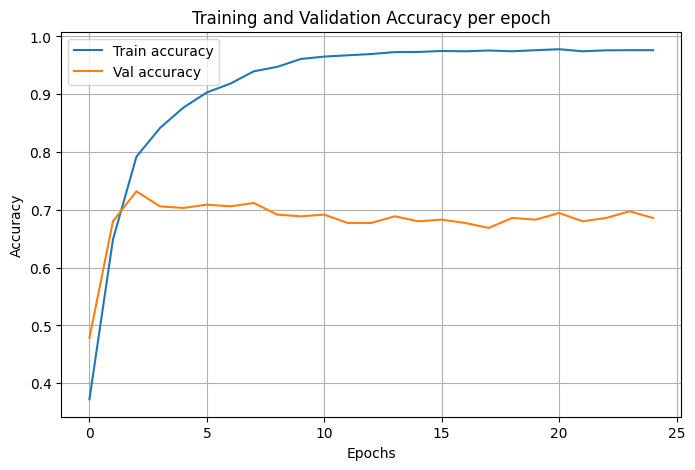

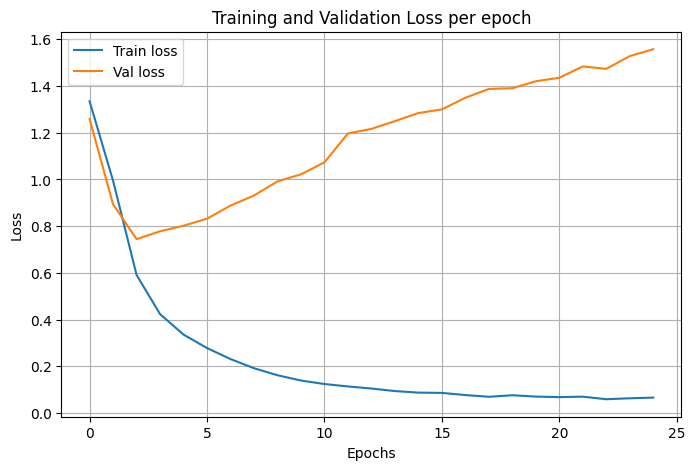


Interpretation:

1. Accuracy Plot:
   * The Training Accuracy (blue line) starts low and increases rapidly, approaching nearly 1.0 (or 100%). This indicates the model is learning the training data very well.
   * The Validation Accuracy (orange line) increases initially but then plateaus around epoch 3-4 and starts to slightly decrease or fluctuate afterwards. It reaches a peak around 70-73% accuracy.
   * The gap between the training accuracy and validation accuracy continuously widens after the initial epochs.

2. Loss Plot:
   * The Training Loss (blue line) starts relatively high and decreases steadily throughout the training, approaching zero. This shows the model is minimizing its error on the training data.
   * The Validation Loss (orange line) decreases initially (up to epoch 3 approximately) but then starts to increase consistently for the rest of the training.
   * The point where the validation loss starts to increase while the training loss continues to decrease is a clea

In [47]:
# Answer here
import matplotlib.pyplot as plt
import pandas as pd

try:
    training_log = pd.read_csv("./DM2025-Lab2-Exercise/logs/training_log.csv")
except FileNotFoundError:
    print("Error: training_log.csv not found. Make sure the path is correct and the training cell was run.")
    training_log = None

if training_log is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(training_log['epoch'], training_log['accuracy'], label='Train accuracy')
    plt.plot(training_log['epoch'], training_log['val_accuracy'], label='Val accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy per epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot Loss ---
    plt.figure(figsize=(8, 5))
    plt.plot(training_log['epoch'], training_log['loss'], label='Train loss')
    plt.plot(training_log['epoch'], training_log['val_loss'], label='Val loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss per epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\nInterpretation:\n")
    print("1. Accuracy Plot:")
    print("   * The Training Accuracy (blue line) starts low and increases rapidly, approaching nearly 1.0 (or 100%). This indicates the model is learning the training data very well.")
    print("   * The Validation Accuracy (orange line) increases initially but then plateaus around epoch 3-4 and starts to slightly decrease or fluctuate afterwards. It reaches a peak around 70-73% accuracy.")
    print("   * The gap between the training accuracy and validation accuracy continuously widens after the initial epochs.\n")
    print("2. Loss Plot:")
    print("   * The Training Loss (blue line) starts relatively high and decreases steadily throughout the training, approaching zero. This shows the model is minimizing its error on the training data.")
    print("   * The Validation Loss (orange line) decreases initially (up to epoch 3 approximately) but then starts to increase consistently for the rest of the training.")
    print("   * The point where the validation loss starts to increase while the training loss continues to decrease is a clear sign of overfitting.\n")
    print("3. Relation to Overfitting/Underfitting:")
    print("   * Underfitting might be present in the very early epochs (e.g., epoch 0-1) where both training and validation performance are low and improving.")
    print("   * Overfitting becomes evident around epoch 3-4. At this point:")
    print("       * Training accuracy continues to improve significantly, while validation accuracy stagnates or worsens.")
    print("       * Training loss continues to decrease, while validation loss starts to increase.")
    print("   * This divergence indicates that the model is learning patterns specific to the training data (including noise) that do not generalize to the unseen validation data. The model becomes too complex for the underlying patterns in the data distribution. The optimal point to stop training would likely have been around epoch 3, where validation loss was minimal and validation accuracy was near its peak.")

---

### <a id='toc1_10_6_'></a>[Note](#toc0_)

If you don't have a GPU (level is higher than GTX 1060) or you are not good at setting lots of things about computer, we recommend you to use the [kaggle kernel](https://www.kaggle.com/kernels) to do deep learning model training. They have already installed all the librarys and provided free GPU for you to use.

Note however that you will only be able to run a kernel for 6 hours. After 6 hours of inactivity, your Kaggle kernel will shut down (meaning if your model takes more than 6 hours to train, you can't train it at once).


### <a id='toc1_10_7_'></a>[More Information for your reference](#toc0_)

* Keras document: https://keras.io/
* Keras GitHub example: https://github.com/keras-team/keras/tree/master/examples
* CS229: Machine Learning: http://cs229.stanford.edu/syllabus.html
* Deep Learning cheatsheet: https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-deep-learning
* If you want to try TensorFlow or PyTorch: https://pytorch.org/tutorials/
https://www.tensorflow.org/tutorials/quickstart/beginner

---
## <a id='toc1_11_'></a>[**7. Word2Vector**](#toc0_)

We will introduce how to use `gensim` to train your word2vec model and how to load a pre-trained model.

https://radimrehurek.com/gensim/index.html

---
### <a id='toc1_11_1_'></a>[**7.1 Prepare training corpus**](#toc0_)

In [48]:
## check library
import gensim

## ignore warnings
import warnings
warnings.filterwarnings('ignore')

# # if you want to see the training messages, you can use it
# import logging
# logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

## the input type
train_df['text_tokenized'] = train_df['text'].apply(lambda x: nltk.word_tokenize(x))
train_df[['id', 'text', 'text_tokenized']].head()

,id,text,text_tokenized
511,10511,@LouisFil just curious as to what you mean. No...,"[@, LouisFil, just, curious, as, to, what, you..."
1503,20646,@ZaidZamanHamid Speech is still not up to the ...,"[@, ZaidZamanHamid, Speech, is, still, not, up..."
2755,30751,"Hey @AppleSupport, would be nice to have “clic...","[Hey, @, AppleSupport, ,, would, be, nice, to,..."
1466,20609,@Joey7Barton I remember Joey slagging England ...,"[@, Joey7Barton, I, remember, Joey, slagging, ..."
3107,40280,"@PaulJonMilne too grim, too insanely, determin...","[@, PaulJonMilne, too, grim, ,, too, insanely,..."


In [49]:
## create the training corpus
training_corpus = train_df['text_tokenized'].values
training_corpus[:3]

array([list(['@', 'LouisFil', 'just', 'curious', 'as', 'to', 'what', 'you', 'mean', '.', 'No', 'rush', ',', 'no', 'animosity', ',', 'no', 'disdain', '.']),
       list(['@', 'ZaidZamanHamid', 'Speech', 'is', 'still', 'not', 'up', 'to', 'the', 'mark', '.', 'No', 'mention', 'of', "'Genocide", "'", ',', 'Indian', 'terrorism', 'in', 'Pak', '.', 'It', 'was', 'all', 'planned', 'speech', '.']),
       list(['Hey', '@', 'AppleSupport', ',', 'would', 'be', 'nice', 'to', 'have', '“', 'click', 'to', 'pause', '”', 'or', '“', 'pause', 'when', 'window', 'inactive', '”', 'on', 'animated', 'GIFs', 'for', 'macOS', 'Messages', 'app'])],
      dtype=object)

---
### <a id='toc1_11_2_'></a>[**7.2 Training our model**](#toc0_)

You can try to train your own model. More details: https://radimrehurek.com/gensim/models/word2vec.html

In [50]:
from gensim.models import Word2Vec

## setting
vector_dim = 100
window_size = 5
min_count = 1
training_epochs = 20

## model
word2vec_model = Word2Vec(sentences=training_corpus,
                          vector_size=vector_dim, window=window_size,
                          min_count=min_count, epochs=training_epochs)

![Imgur](https://i.imgur.com/Fca3MCs.png)

---
### <a id='toc1_11_3_'></a>[**7.3 Generating word vector (embeddings)**](#toc0_)

In [51]:
# get the corresponding vector of a word
word_vec = word2vec_model.wv['happy']
word_vec

array([ 0.42298046,  0.14433669, -0.00836845,  0.11560313, -0.33319178,
       -1.0541574 ,  0.46157083,  1.3890431 , -0.66785204, -0.7592593 ,
       -0.46720546, -0.58847135, -0.7065374 ,  0.4482624 , -0.3110598 ,
       -0.14033988,  0.17480806, -0.6884829 , -0.03516126, -1.384459  ,
        0.6894538 ,  0.5532775 ,  0.6447345 , -0.10533535,  0.13621353,
        0.02898386, -0.91220874,  0.52297807, -0.1601224 ,  0.35144284,
        0.38901338, -0.17183168,  0.53906375, -0.3242087 , -0.2558152 ,
        0.6837453 ,  0.5369227 , -0.30866304, -0.5915171 , -0.51254946,
        0.44103533,  0.3596597 , -0.20700501,  0.58529925,  0.9908138 ,
        0.00807945, -0.5611913 , -0.30751917,  0.7158469 ,  0.26248503,
       -0.01390237,  0.01850292,  0.51738226,  0.04241258, -0.6421451 ,
       -0.38587028,  0.04534003, -0.24121107, -0.32947707, -0.43307966,
        0.37273166,  0.09710031,  0.1935108 ,  0.07655823, -0.7442573 ,
        0.64461565,  0.24207963,  0.52487856, -1.3782254 ,  0.32

In [52]:
# Get the most similar words
word = 'happy'
topn = 10
word2vec_model.wv.most_similar(word, topn=topn)

[('birthday', 0.9574775695800781),
 ('help', 0.9395856261253357),
 ("'you", 0.9272278547286987),
 ('Be', 0.9173905253410339),
 ('blessed', 0.9127157926559448),
 ('infuriate', 0.9113531708717346),
 ('free', 0.9021779894828796),
 ('blessing', 0.8990228772163391),
 ('.\\nA', 0.8971728086471558),
 ('cry', 0.8954051733016968)]

---
### <a id='toc1_11_4_'></a>[**7.4 Using a pre-trained w2v model**](#toc0_)

Instead of training your own model ,you can use a model that has already been trained. Here, we see 2 ways of doing that:


#### <a id='toc1_11_4_1_'></a>[(1) Download model by yourself](#toc0_)

source: [GoogleNews-vectors-negative300](https://code.google.com/archive/p/word2vec/)

more details: https://radimrehurek.com/gensim/models/keyedvectors.html

In [53]:
from gensim.models import KeyedVectors

## Note: this model is huge, this will take some time ...
model_path = f"{google_news_vectors_path}/GoogleNews-vectors-negative300.bin"
w2v_google_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
print('load ok')

w2v_google_model.most_similar('happy', topn=10)

load ok


[('glad', 0.7408890724182129),
 ('pleased', 0.6632170677185059),
 ('ecstatic', 0.6626912355422974),
 ('overjoyed', 0.6599286794662476),
 ('thrilled', 0.6514049172401428),
 ('satisfied', 0.6437949538230896),
 ('proud', 0.636042058467865),
 ('delighted', 0.627237856388092),
 ('disappointed', 0.6269949674606323),
 ('excited', 0.6247665286064148)]

#### <a id='toc1_11_4_2_'></a>[(2) Using gensim api](#toc0_)

Other pretrained models are available here: https://github.com/RaRe-Technologies/gensim-data

In [54]:
import gensim.downloader as api

## If you see `SSL: CERTIFICATE_VERIFY_FAILED` error, use this:
import ssl
import urllib.request
ssl._create_default_https_context = ssl._create_unverified_context

glove_twitter_25_model = api.load("glove-twitter-25")
print('load ok')

glove_twitter_25_model.most_similar('happy', topn=10)

[==================================================] 100.0% 104.8/104.8MB downloaded
load ok


[('birthday', 0.9577818512916565),
 ('thank', 0.937666654586792),
 ('welcome', 0.93361496925354),
 ('love', 0.9176183342933655),
 ('miss', 0.9164500832557678),
 ('hello', 0.9158351421356201),
 ('thanks', 0.915008544921875),
 ('merry', 0.9053249359130859),
 ('bless', 0.902732253074646),
 ('wish', 0.9013164043426514)]

---
### <a id='toc1_11_5_'></a>[**7.5 king + woman - man = ?**](#toc0_)

Let's run one of the most famous examples for Word2Vec and compute the similarity between these 3 words:

In [55]:
w2v_google_model.most_similar(positive=['king', 'woman'], negative=['man'])

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.5499460697174072),
 ('prince', 0.5377321839332581),
 ('kings', 0.5236844420433044),
 ('Queen_Consort', 0.5235945582389832),
 ('queens', 0.5181134343147278),
 ('sultan', 0.5098593831062317),
 ('monarchy', 0.5087411999702454)]

---
##### <a id='toc1_11_5_1_1_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

Now, we have the word vectors, but our input data is a sequence of words (or say sentence).
How can we utilize these "word" vectors to represent the sentence data and train our model?


In [ ]:
# Answer here


To represent sentence data using word vectors (like those from Word2Vec) for training a model that requires a fixed-size input, we need to aggregate the vectors of the words in the sentence into a single, fixed-dimension sentence vector. Common methods include:

1.  **Averaging Word Vectors**:
    * Sum the vectors of all words in the sentence.
    * Divide the resulting sum vector by the number of words in the sentence.
    * This creates a sentence vector that represents the average semantic meaning, but it ignores word order.

2.  **Summing Word Vectors**:
    * Simply sum the vectors of all words in the sentence without dividing.
    * This is simpler but can result in vectors with very different magnitudes depending on sentence length, and it also ignores word order.

3.  **TF-IDF Weighted Averaging**:
    * Similar to averaging, but before summing/averaging, multiply each word vector by its TF-IDF score (or another importance weight).
    * This gives more weight to important words in the sentence vector calculation.
    * It still ignores word order.

4.  **Max/Min Pooling**:
    * Create a sentence vector where each dimension is the maximum (Max Pooling) or minimum (Min Pooling) value found in that dimension across all word vectors in the sentence.
    * This captures the most salient feature values but loses other information and word order.

5.  **Using Sequence Models (More Advanced)**:
    * Models like Recurrent Neural Networks (RNNs, LSTMs, GRUs), Convolutional Neural Networks (CNNs), or Transformers can take the sequence of word vectors as direct input.
    * These models learn to process the sequence, considering word order and context, and can output a fixed-size vector representation (e.g., the final hidden state of an RNN or a special token's output in Transformers). This is often more powerful but requires a more complex model architecture.

For many standard classifiers (like those used earlier in the lab or simple DNNs), averaging the word vectors (Method 1) is a common and straightforward starting point to get a fixed-size sentence representation.

---
## <a id='toc1_12_'></a>[**8. Clustering: k-means**](#toc0_)

Here we introduce how to use `sklearn` to do the basic **unsupervised learning** approach, k-means.    

more details: http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


#### <a id='toc1_12_1_1_'></a>[Basic concept](#toc0_)

![pic5.png](https://drive.google.com/uc?export=view&id=1YaPsXWrr7sQFHelMyiNuERs2lG1tZZ54)

(img source: https://towardsdatascience.com/k-means-clustering-identifying-f-r-i-e-n-d-s-in-the-world-of-strangers-695537505d)

In [56]:
# clustering target
target_list = ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']
print('target words: ', target_list)

# convert to word vector
X = [word2vec_model.wv[word] for word in target_list]

target words:  ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']


In [57]:
from sklearn.cluster import KMeans

# we have to decide how many cluster (k) we want
k = 2

# k-means model
kmeans_model = KMeans(n_clusters=k)
kmeans_model.fit(X)

# cluster result
cluster_result = kmeans_model.labels_

# show
for i in range(len(target_list)):
    print('word: {} \t cluster: {}'.format(target_list[i], cluster_result[i]))

word: happy 	 cluster: 0
word: fear 	 cluster: 0
word: angry 	 cluster: 0
word: car 	 cluster: 1
word: teacher 	 cluster: 1
word: computer 	 cluster: 1


![pic6.png](https://drive.google.com/uc?export=view&id=1loQX4BJI3MlcNmlpjVvqqNTLQSOmxfC4)

In [58]:
#check cluster membership
word = 'student'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([1], dtype=int32)

In [59]:
#check cluster membership
word = 'sad'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([0], dtype=int32)

---
## <a id='toc1_13_'></a>[**9. High-dimension Visualization: t-SNE and UMAP**](#toc0_)

No matter if you use the Bag-of-words, TF-IDF, or Word2Vec, it's very hard to see the embedding result, because the dimension is larger than 3.  

In Lab 1, we already talked about PCA, t-SNE and UMAP. We can use PCA to reduce the dimension of our data, then visualize it. However, if you dig deeper into the result, you'd find it is insufficient.

Our aim will be to create a visualization similar to the one below with t-SNE:

![pic7.png](https://drive.google.com/uc?export=view&id=1YgtPqQJysWiWKCOvGVjpA07gwgqap3a6)

source: https://www.fabian-keller.de/research/high-dimensional-data-visualization

And also like this for UMAP:

![pic9.png](https://drive.google.com/uc?export=view&id=1NQsoRSWGYAya0dyDefPXYy7l7Ag6a5UT)

source: https://umap-learn.readthedocs.io/en/latest/auto_examples/plot_mnist_example.html

t-SNE and UMAP reference:  
http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
https://umap-learn.readthedocs.io/en/latest/

---
### <a id='toc1_13_1_'></a>[**9.1 Prepare visualizing target**](#toc0_)

Let's prepare data lists like:
- happy words
- angry words
- data words
- mining words

In [60]:
word_list = ['happy', 'angry', 'data', 'mining']

topn = 5
happy_words = ['happy'] + [word_ for word_, sim_ in w2v_google_model.most_similar('happy', topn=topn)]
angry_words = ['angry'] + [word_ for word_, sim_ in w2v_google_model.most_similar('angry', topn=topn)]
data_words = ['data'] + [word_ for word_, sim_ in w2v_google_model.most_similar('data', topn=topn)]
mining_words = ['mining'] + [word_ for word_, sim_ in w2v_google_model.most_similar('mining', topn=topn)]

print('happy_words: ', happy_words)
print('angry_words: ', angry_words)
print('data_words: ', data_words)
print('mining_words: ', mining_words)

target_words = happy_words + angry_words + data_words + mining_words
print('\ntarget words: ')
print(target_words)

print('\ncolor list:')
cn = topn + 1
color = ['b'] * cn + ['g'] * cn + ['r'] * cn + ['y'] * cn
print(color)

happy_words:  ['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled']
angry_words:  ['angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed']
data_words:  ['data', 'Data', 'datasets', 'dataset', 'databases', 'statistics']
mining_words:  ['mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

target words: 
['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled', 'angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed', 'data', 'Data', 'datasets', 'dataset', 'databases', 'statistics', 'mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

color list:
['b', 'b', 'b', 'b', 'b', 'b', 'g', 'g', 'g', 'g', 'g', 'g', 'r', 'r', 'r', 'r', 'r', 'r', 'y', 'y', 'y', 'y', 'y', 'y']


---
### <a id='toc1_13_2_'></a>[**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc0_)

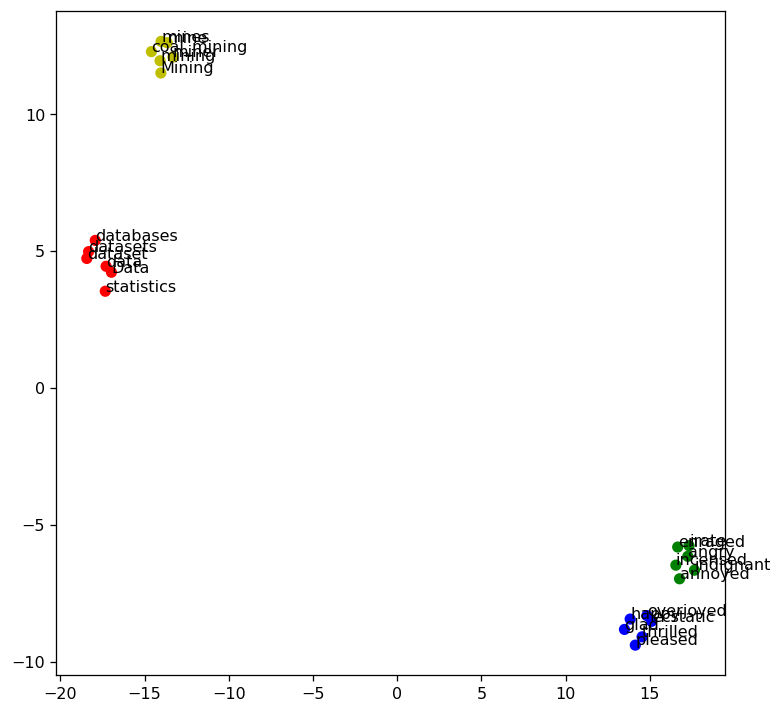

In [61]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## t-SNE model
tsne = TSNE(n_components=2, metric='cosine', random_state=28)

## training
X_tsne = tsne.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_tsne[:target_size, 0], X_tsne[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_tsne[:target_size, 0], X_tsne[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()

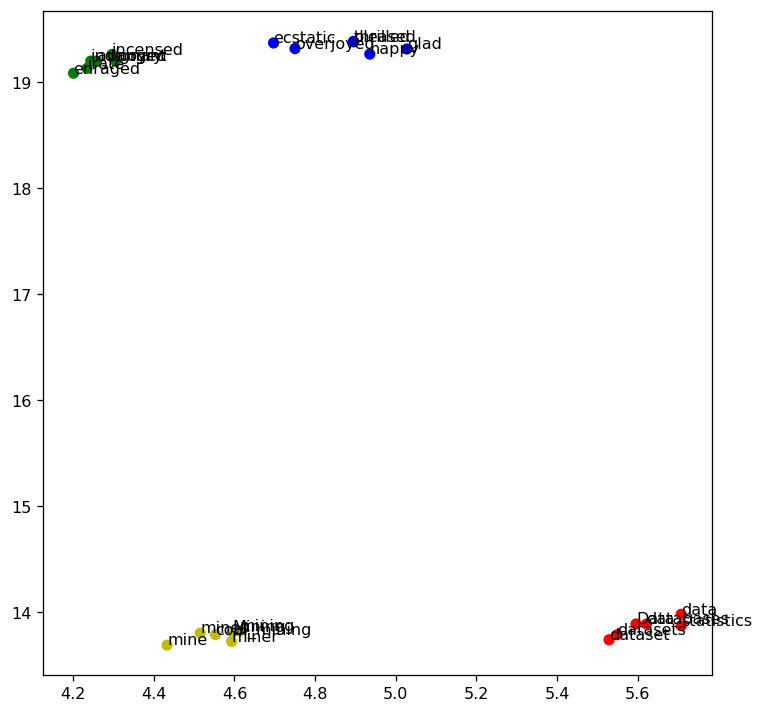

In [62]:
import matplotlib.pyplot as plt
import umap.umap_ as umap

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## UMAP model
umap_model = umap.UMAP(n_components=2, metric='cosine', random_state=28)

## training
X_umap = umap_model.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_umap[:target_size, 0], X_umap[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_umap[:target_size, 0], X_umap[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()


---
##### <a id='toc1_13_2_1_1_'></a>[**>>> Exercise 8 (Take home):**](#toc0_)

Generate a t-SNE and UMAP visualization to show the 15 words most related to the words "angry", "happy", "sad", "fear" (60 words total). Compare the differences between both graphs.

Total target words: 64


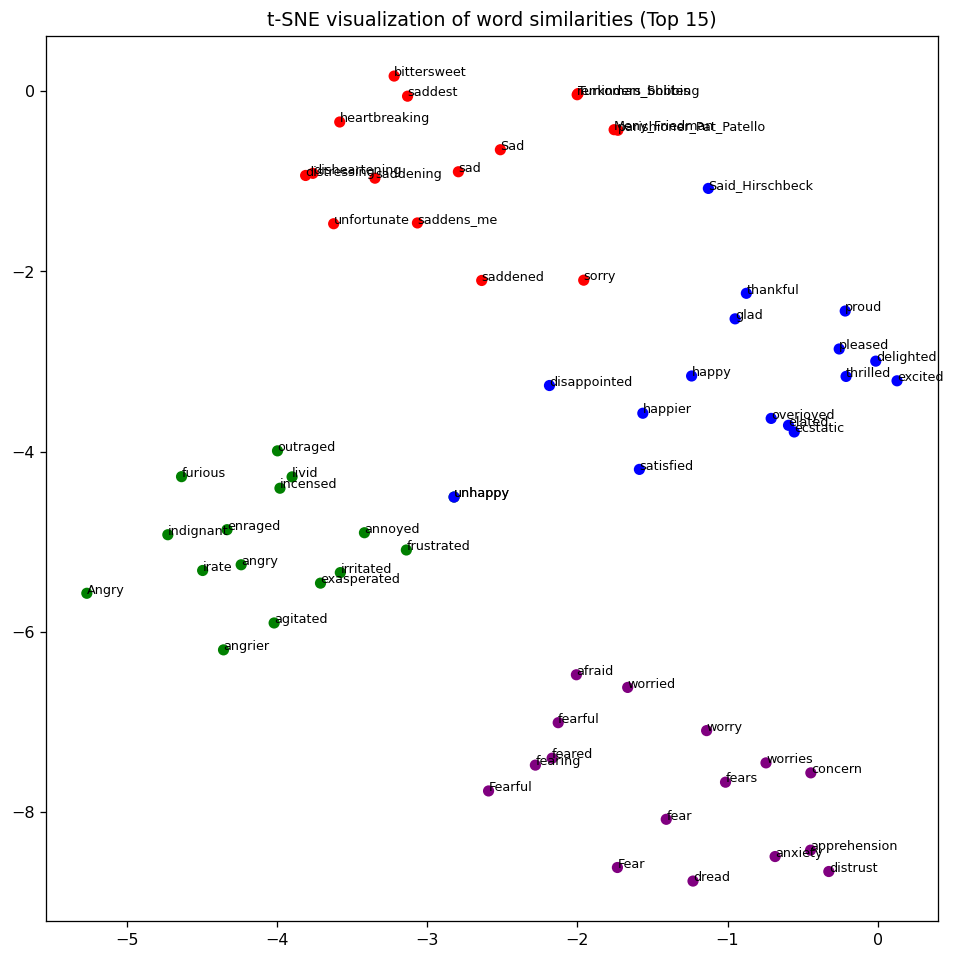

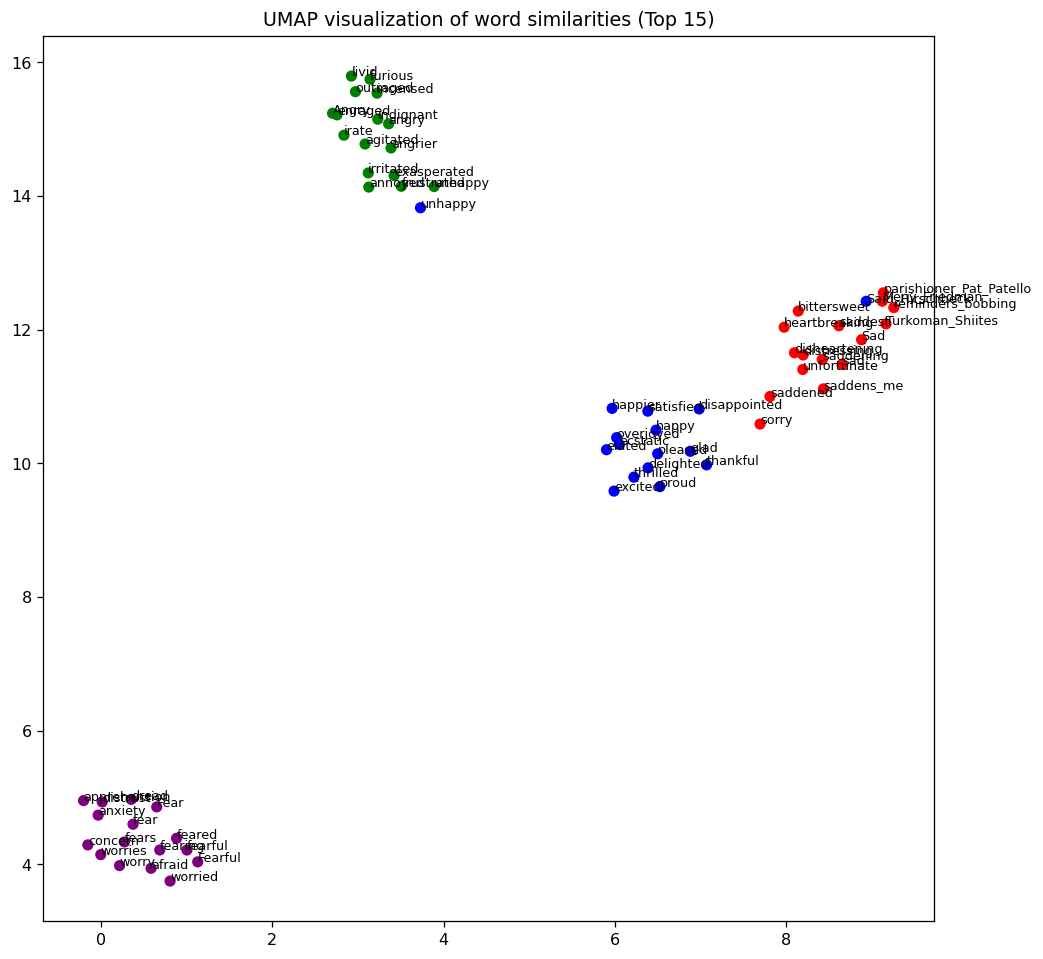


Comparison between t-SNE and UMAP visualizations:

1.  **Cluster Separation**:
    * Both t-SNE and UMAP generally manage to separate the four semantic groups ('angry', 'happy', 'sad', 'fear') into distinct clusters.
    * UMAP often produces tighter, more compact clusters with potentially clearer separation between them compared to t-SNE, which might spread clusters out more.

2.  **Intra-cluster Structure**:
    * t-SNE tends to create roughly spherical clusters and focuses on preserving local structure (keeping nearest neighbors close). The relative distances *between* points *within* a t-SNE cluster might not be very meaningful.
    * UMAP often does a better job of preserving the global structure and the relative distances between points within a cluster. You might observe more defined shapes or sub-structures within UMAP clusters. For example, words that are very close synonyms might appear closer together in the UMAP plot than in the t-SNE plot.

3.  **Global Structure / Inter-

In [64]:
# Answer here
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap
import numpy as np

seed_words = ['angry', 'happy', 'sad', 'fear']
topn = 15
num_seeds = len(seed_words)

# Get the most similar words for each seed word
similar_words_map = {}
target_words = []
colors_list = ['g', 'b', 'r', 'purple']
color = []

for i, word in enumerate(seed_words):
    similar_words = [word] + [sim_word for sim_word, _ in model.most_similar(word, topn=topn)]
    similar_words_map[word] = similar_words
    target_words.extend(similar_words)
    color.extend([colors_list[i]] * (topn + 1))

print(f'Total target words: {len(target_words)}')

target_size = len(target_words)
X_train_ex8 = model[target_words]

# --- t-SNE Visualization ---
# Removed the n_iter argument as it's unexpected in this version
tsne_ex8 = TSNE(n_components=2, metric='cosine', random_state=28, perplexity=30) # Common TSNE settings
X_tsne_ex8 = tsne_ex8.fit_transform(X_train_ex8)

plt.figure(figsize=(10, 10), dpi=115) # Increase figure size
plt.scatter(X_tsne_ex8[:, 0], X_tsne_ex8[:, 1], c=color)
for label, x, y in zip(target_words, X_tsne_ex8[:, 0], X_tsne_ex8[:, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0), textcoords='offset points', fontsize=8) # Reduce fontsize slightly
plt.title('t-SNE visualization of word similarities (Top 15)')
plt.show()

# --- UMAP Visualization --- # (Keep the UMAP part as it was)
umap_ex8 = umap.UMAP(n_components=2, metric='cosine', random_state=28, n_neighbors=10, min_dist=0.1) # Common UMAP settings
X_umap_ex8 = umap_ex8.fit_transform(X_train_ex8)

plt.figure(figsize=(10, 10), dpi=115) # Increase figure size
plt.scatter(X_umap_ex8[:, 0], X_umap_ex8[:, 1], c=color)
for label, x, y in zip(target_words, X_umap_ex8[:, 0], X_umap_ex8[:, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0), textcoords='offset points', fontsize=8) # Reduce fontsize slightly
plt.title('UMAP visualization of word similarities (Top 15)')
plt.show()

# --- Comparison --- # (Keep the comparison print statement as corrected before)
print("""
Comparison between t-SNE and UMAP visualizations:

1.  **Cluster Separation**:
    * Both t-SNE and UMAP generally manage to separate the four semantic groups ('angry', 'happy', 'sad', 'fear') into distinct clusters.
    * UMAP often produces tighter, more compact clusters with potentially clearer separation between them compared to t-SNE, which might spread clusters out more.

2.  **Intra-cluster Structure**:
    * t-SNE tends to create roughly spherical clusters and focuses on preserving local structure (keeping nearest neighbors close). The relative distances *between* points *within* a t-SNE cluster might not be very meaningful.
    * UMAP often does a better job of preserving the global structure and the relative distances between points within a cluster. You might observe more defined shapes or sub-structures within UMAP clusters. For example, words that are very close synonyms might appear closer together in the UMAP plot than in the t-SNE plot.

3.  **Global Structure / Inter-cluster Distances**:
    * The distances *between* clusters in t-SNE are generally not reliable indicators of the actual distances between groups in the high-dimensional space.
    * UMAP tends to represent the distances between clusters more faithfully, giving a potentially better sense of how separated or related the different semantic groups are overall. For instance, the negative emotion clusters ('angry', 'sad', 'fear') might appear relatively closer to each other than to the 'happy' cluster in the UMAP plot.

4.  **Computational Speed**: Although not directly visible in the plots, UMAP is generally significantly faster than t-SNE, especially for larger datasets.

Overall, while both methods visualize the separation of semantic groups, UMAP often provides a visualization that better reflects both the local and global structure of the high-dimensional word vectors.
""")

---